# Hydro Storage Scheduling under Price Uncertainty (TAS1)

Tasmania's electricity is ~80% hydro. The reservoirs are not just
generation — they are *energy storage*. So Hydro Tasmania's daily
problem is the canonical one in energy economics: when do you let the
water through, and when do you hold it back?

This notebook is laid out as a short paper —
**Introduction**, **Data**, **Methods**, **Results**, **Conclusion**.
Inside Methods it builds the answer in **seven progressively richer
chapters**:

> spectral characterisation → Bayesian ARMA-GARCH (numpyro) →
> Markov-switching regime model → reservoir simulator →
> risk-neutral SDP → risk-averse CVaR-SDP → deep RL benchmark
> (PPO from scratch in PyTorch) → perfect-foresight LP upper bound.

Each plot is followed by a short note covering what to look at, what
it means, and what it indicates next.

## 1. Introduction

*The problem, why TAS1 is the right setting, and what each chapter
delivers.*

A reservoir hydro operator solves a stochastic optimal control
problem every day. State: how much water is in the dam. Action: how
much to dispatch. Exogenous uncertainty: future prices and inflows.
The textbook answer is stochastic dynamic programming; the
practical answer that gets shipped is usually rule-of-thumb. This
notebook walks through both, plus a deep-RL benchmark and a
risk-aware variant that operations would actually care about.

The central question I'm chasing: **how does the optimal dispatch
policy shift as we improve the price model and as we change the
operator's risk preferences?**

## 2. Data

*TAS1 prices for 2022–2024, 30-minute trading intervals, pulled via
NEMOSIS.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import models
import plots
import spectral
import bayes_garch
import ms_garch
import cvar_sdp
import drl

plots.apply_style()

df = data.load_tas1_price("2022/01/01 00:00:00", "2025/01/01 00:00:00")
df = data.add_calendar(df)
prices = df["rrp"].values.astype(np.float64)
print(f"rows: {len(df):,}  range: {df['SETTLEMENTDATE'].min()} -> {df['SETTLEMENTDATE'].max()}")
print(f"price summary:\n{df['rrp'].describe().round(1)}")

INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
rows: 52,608  range: 2022-01-01 00:30:00 -> 2025-01-01 00:00:00
price summary:
count    52608.0
mean        99.5
std        241.3
min       -924.2
25%         35.3
50%         72.8
75%        125.3
max      16600.0
Name: rrp, dtype: float64


### 2.1 Three years of TAS1 prices

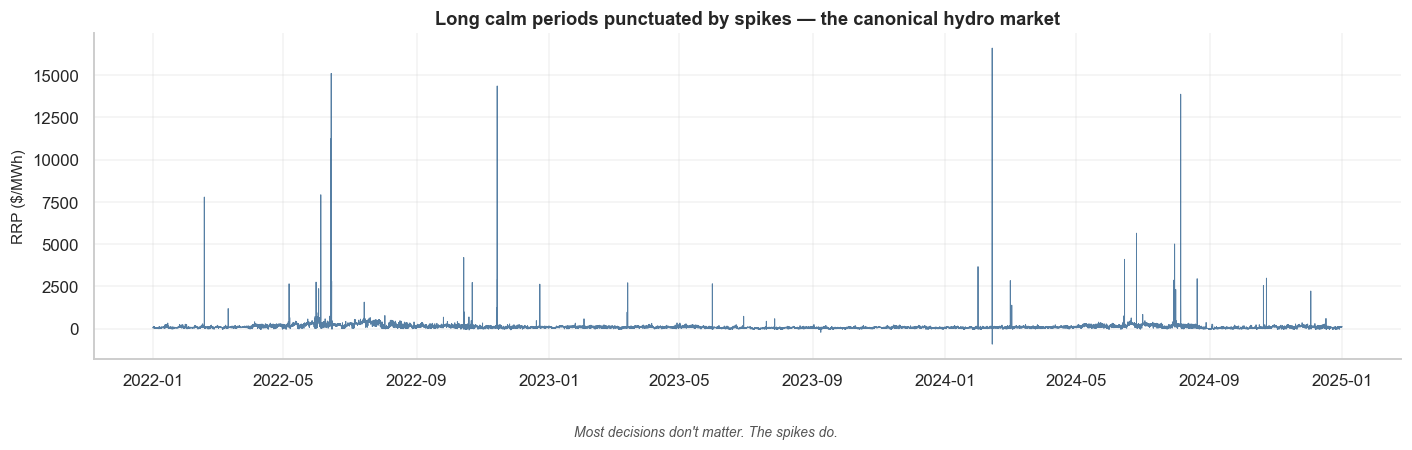

In [2]:
fig, ax = plt.subplots(figsize=(13, 3.8))
plots.price_overview(df, ax=ax)
ax.set_title("Long calm periods punctuated by spikes — the canonical hydro market")
plots.caption(fig, "Most decisions don't matter. The spikes do.")
plt.tight_layout(); plt.show()

**What to look at:** the frequency and magnitude of spikes vs
the typical level. **What it means:** most half-hours sit in a fairly
narrow band, but extreme events push price an order of magnitude
above the median. **What it indicates:** the option value of holding
water *is* the spikes, so any decent model has to capture spike
statistics — not just the mean.

## 3. Methods

*Seven chapters, ordered from a description of the price series to
the dispatch policies that act on it.*

### 3.1 Spectral characterisation — multi-scale structure

A wavelet transform exposes the timescales that carry the variance:
the daily cycle, the weekly cycle, and the high-frequency residual
where forecastable volatility lives.

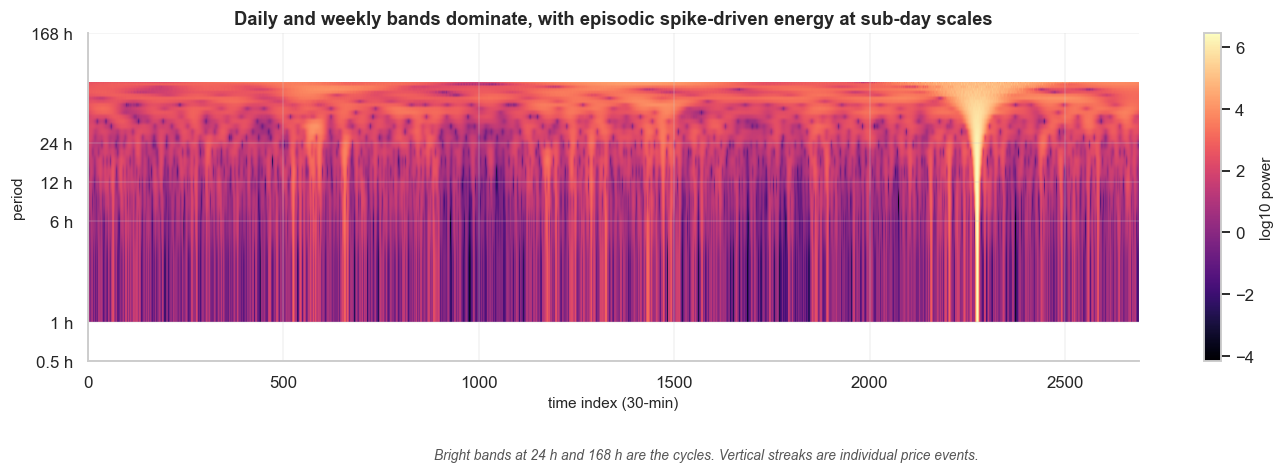

In [3]:
# CWT is expensive on long series; take a representative two-month
# slice at native resolution and cap the longest period at 3 days.
prices_cwt = prices[:8 * 7 * 48]   # ~8 weeks
coeffs, periods_hours = spectral.cwt_morlet(
    prices_cwt, dt_minutes=30, n_scales=24,
    freq_low_hz=1 / (3 * 24 * 3600),
    freq_high_hz=1 / (60 * 60),
)
fig, ax = plt.subplots(figsize=(13, 4))
plots.scalogram(coeffs, periods_hours, ax=ax)
ax.set_title("Daily and weekly bands dominate, with episodic spike-driven energy at sub-day scales")
plots.caption(fig, "Bright bands at 24 h and 168 h are the cycles. Vertical streaks are individual price events.")
plt.tight_layout(); plt.show()

**What to look at:** the persistent horizontal bands and the
sporadic vertical streaks. **What it means:** seasonality lives on
the bands, surprise lives on the streaks. **What it indicates:** the
GARCH model in §3.2 needs to capture both — the mean component for
the bands and the volatility-clustering component for the streaks.

### 3.2 Bayesian ARMA-GARCH(1,1) — full posterior over the noise

Replaces the MLE fit from `arch_model` with a numpyro NUTS posterior.
Why bother: scenario sampling for the SDP later should propagate
*parameter* uncertainty, not just one ARMA-GARCH realisation.

In [4]:
# Train/test split on the price series
split_idx = int(len(prices) * 0.80)
train_prices = prices[:split_idx]
test_prices = prices[split_idx:]

shift = max(0.0, -train_prices.min() + 1.0)
train_returns = np.diff(np.log(train_prices + shift))

# Fit Bayesian GARCH (subsample for tractability — 1-in-4 trading intervals)
mcmc, samples = bayes_garch.fit(train_returns, n_warmup=300, n_samples=300,
                                 sub_every=4, seed=0)
print(f"posterior summary (μ, φ, ω, α, β):")
for name in ["mu", "phi", "omega", "alpha", "beta"]:
    s = np.asarray(samples[name])
    print(f"  {name:6s}  median {np.median(s): .4f}  90% CI [{np.quantile(s,0.05): .4f}, {np.quantile(s,0.95): .4f}]")

posterior summary (μ, φ, ω, α, β):
  mu      median -0.0000  90% CI [-0.0009,  0.0009]
  phi     median -0.0214  90% CI [-0.0525,  0.0119]
  omega   median  0.0005  90% CI [ 0.0004,  0.0005]
  alpha   median  0.0804  90% CI [ 0.0682,  0.0903]
  beta    median  0.8284  90% CI [ 0.8169,  0.8413]


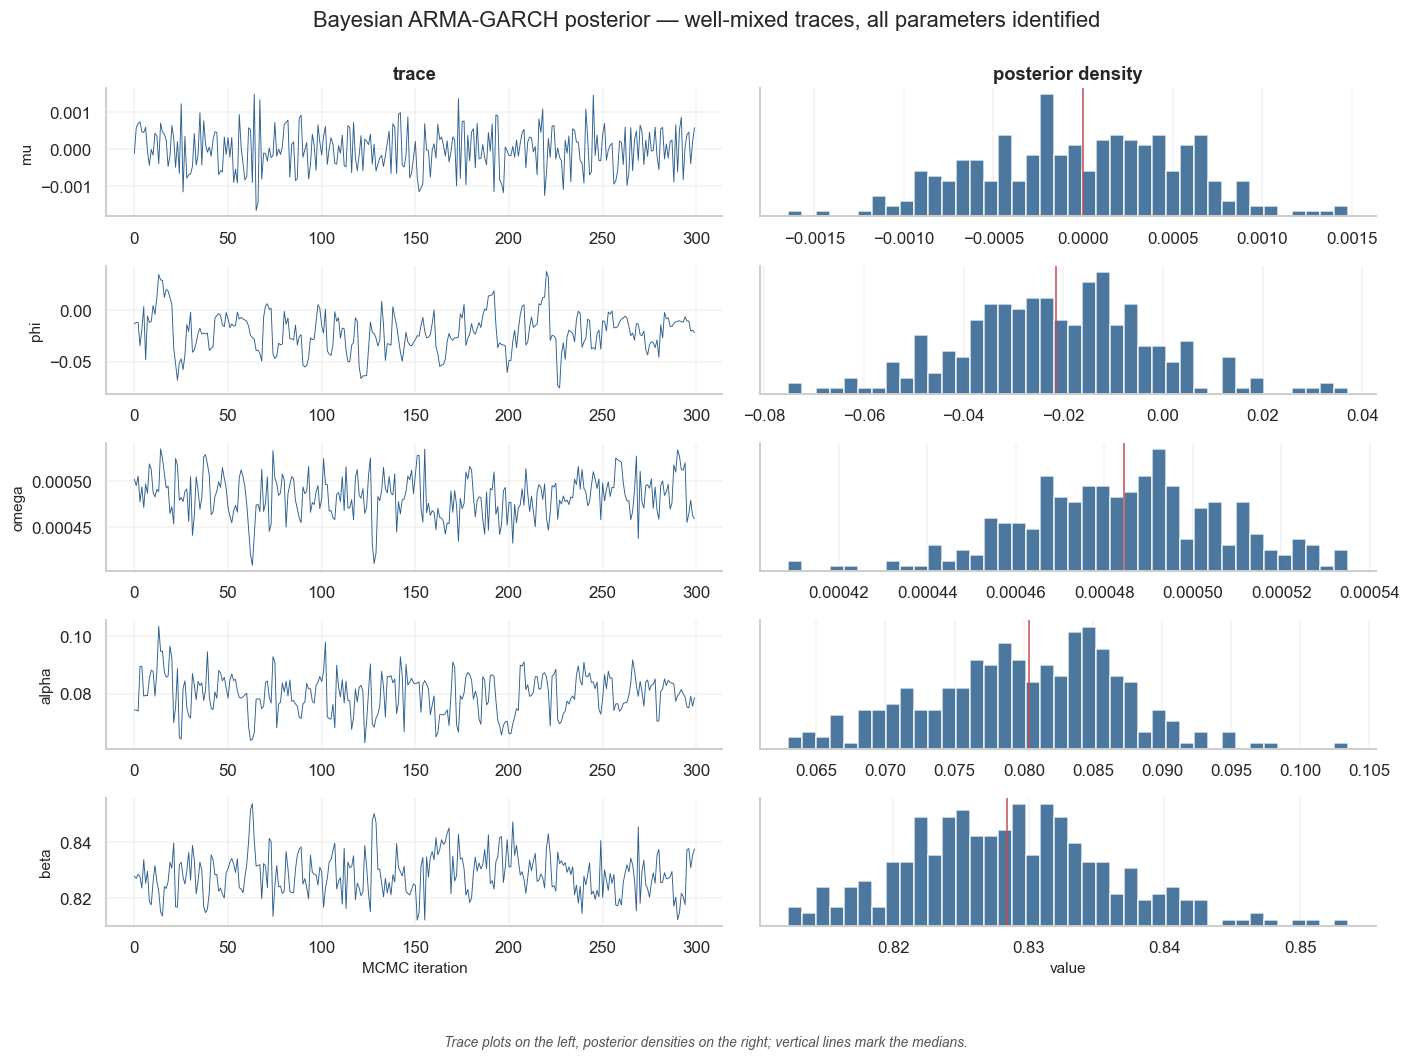

In [5]:
fig, axes = plt.subplots(5, 2, figsize=(13, 9))
plots.posterior_pair(samples,
    names=["mu", "phi", "omega", "alpha", "beta"], ax=axes)
fig.suptitle("Bayesian ARMA-GARCH posterior — well-mixed traces, all parameters identified", y=0.995)
plots.caption(fig, "Trace plots on the left, posterior densities on the right; vertical lines mark the medians.")
plt.tight_layout(); plt.show()

**What to look at:** the trace plots (left) for any drift or
funnels; the posterior densities (right) for shape. **What it means:**
clean horizontal traces and unimodal posteriors mean the sampler
mixed well. **What it indicates:** the parameter posteriors are
trustworthy and the posterior predictive scenarios in §3.4 reflect
the parameter uncertainty rather than treating point estimates as
exact.

### 3.3 Markov-switching ARCH — explicit regimes

The wavelet showed that some weeks are quiet and some are violent.
The Bayesian GARCH absorbs this through its volatility process, but
the regime structure is implicit. A Markov-switching model makes the
regime an explicit hidden state with its own filtered probability.

In [6]:
# Hamilton filter on a subsampled training set — Nelder-Mead in pure
# Python over the full series is too slow; 1-in-8 still captures the
# regime structure clearly.
returns_sub = train_returns[::8]
params, filt, ll = ms_garch.fit(returns_sub, n_starts=3, seed=0)
p11, p22, mu1, mu2, om1, om2, a1, a2 = params
print(f"regime 1 — mu {mu1:+.3f}, omega {om1:.4f}, alpha {a1:.3f}; persistence {p11:.3f}")
print(f"regime 2 — mu {mu2:+.3f}, omega {om2:.4f}, alpha {a2:.3f}; persistence {p22:.3f}")
print(f"log-likelihood: {ll:.1f}")
prob_high = filt[:, 1] if om2 > om1 else filt[:, 0]
sub_prices_for_plot = train_prices[1::8][:len(prob_high)]

regime 1 — mu -0.000, omega 0.0002, alpha 0.000; persistence 0.919
regime 2 — mu -0.003, omega 0.0443, alpha 0.438; persistence 0.163
log-likelihood: 12200.6


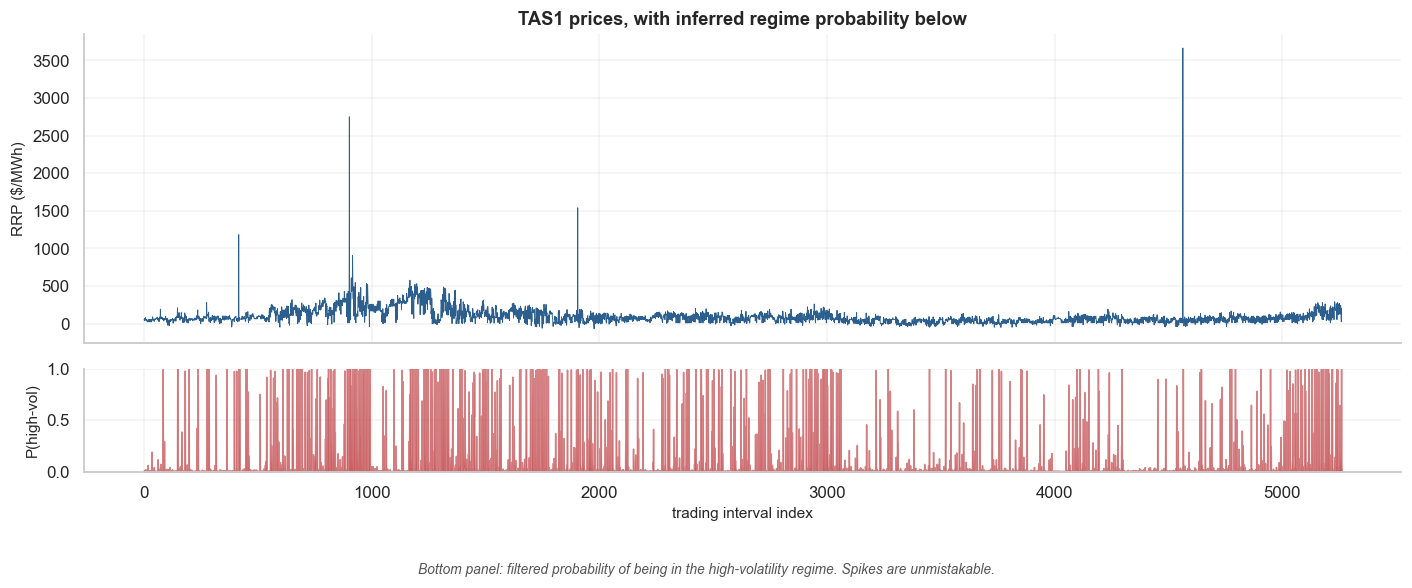

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5),
                          gridspec_kw={"height_ratios": [3, 1]},
                          sharex=True)
plots.regime_ribbon(sub_prices_for_plot, prob_high, ax=axes)
plots.caption(fig, "Bottom panel: filtered probability of being in the high-volatility regime. Spikes are unmistakable.")
plt.tight_layout(); plt.show()

**What to look at:** moments where the lower-panel red ribbon
spikes to ~1, vs the price series above. **What it means:** those are
the half-hours the filter says are in the *high-volatility* regime.
**What it indicates:** the regime switch tracks the actual market
state — quiet baseload weeks vs spike-driven detached-Basslink weeks
— without needing to *tell* the model when those regimes occur.

### 3.4 Reservoir simulator — the physical model

A single hydro unit with linear water dynamics. State `V` is energy
in storage in MWh; action is dispatched MW for the period (one
period = 30 minutes, so MWh out per period = 0.5 × MW). Inflow is an
AR(1) calibrated to a small Tasmanian station.

In [8]:
reservoir = models.Reservoir(
    V_max=5000.0, a_max=200.0, initial_V=2500.0,
    mean_inflow_mwh=25.0, inflow_std=8.0,
)
print(f"capacity: {reservoir.V_max:.0f} MWh, max dispatch: {reservoir.a_max:.0f} MW")

capacity: 5000 MWh, max dispatch: 200 MW


### 3.5 Risk-neutral SDP — backward induction

Discretise the reservoir into 51 levels and the price into 10 deciles
estimated empirically from training data, with a Markov chain on
deciles. Backward induction is a few seconds of numpy.

Bin centres ($/MWh): [  6.1  46.5  70.9 107.5 260.5]
Diagonal of P_trans (persistence): [0.848 0.673 0.652 0.705 0.873]


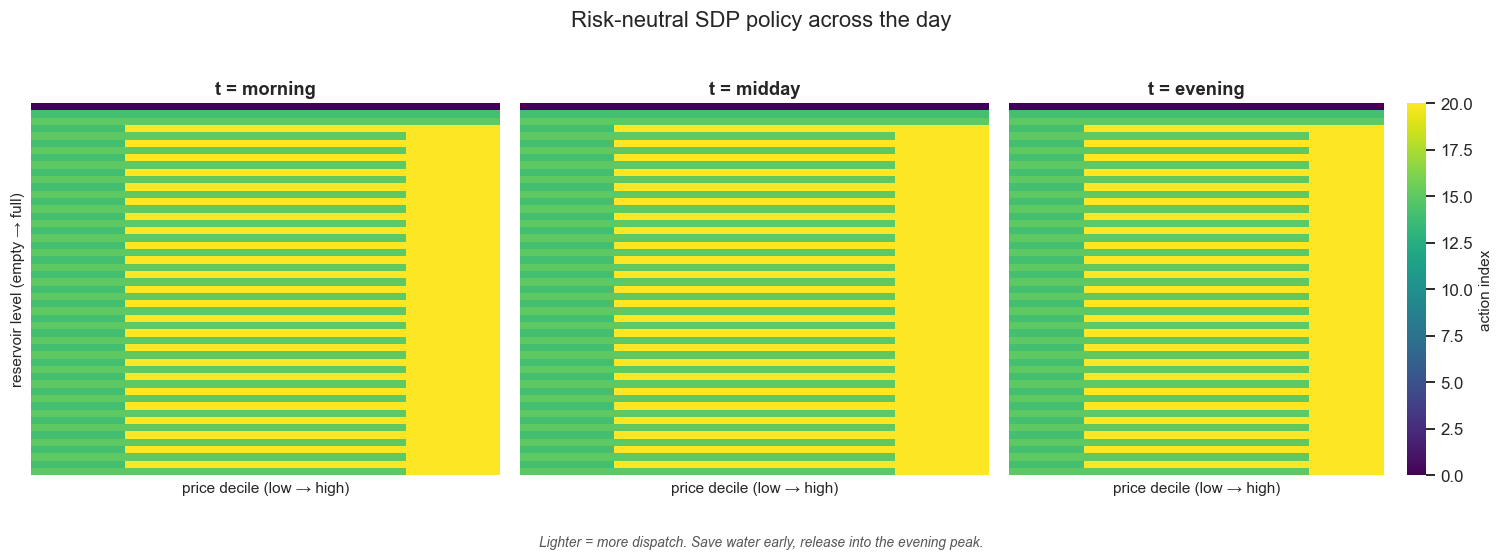

In [9]:
# One-week horizon (336 half-hours): a reservoir of 5000 MWh holds
# only ~25 hours of full dispatch, so over a week the operator must
# ration. That is where the SDP buys real value over the greedy rule.
#
# Five price bins (rather than ten) so each tail bin has enough mass
# (~20%) for CVaR-Bellman to bite at small alpha; with ten bins and a
# highly persistent transition matrix, CVaR collapses to the
# expectation and the risk-aversion sweep degenerates.
HORIZON = 336
N_BINS = 5
P_trans, edges, _ = data.empirical_transition_matrix(train_prices, n_bins=N_BINS)
price_centres = data.bin_centres(train_prices, edges)
print("Bin centres ($/MWh):", price_centres.round(1))
print("Diagonal of P_trans (persistence):", P_trans.diagonal().round(3))

V_grid, a_grid, value_rn, policy_rn = models.solve_sdp(
    reservoir, P_trans, price_centres, T=HORIZON, n_V=51, n_a=21)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
plots.policy_heatmap_grid(
    policy_rn, V_grid,
    t_list=[6, 24, 40],
    titles=["t = morning", "t = midday", "t = evening"],
    axes=axes,
)
fig.suptitle("Risk-neutral SDP policy across the day", y=1.02)
plots.caption(fig, "Lighter = more dispatch. Save water early, release into the evening peak.")
plt.tight_layout(); plt.show()

**What to look at:** the gradient from bottom-left to top-right.
**What it means:** dispatch when price is high *and* the reservoir
is non-empty; otherwise hold. **What it indicates:** the SDP recovers
the qualitative rule-of-thumb but quantifies *exactly where* the
thresholds sit, and how they depend on remaining time in the
horizon.

### 3.6 Risk-averse CVaR-Bellman SDP — what changes when bad
days hurt more?

For a hedge desk or a reliability-first operator, expected-revenue
maximisation is the wrong objective. The Rockafellar-Uryasev
formulation lets us replace the expectation in the Bellman recursion
with a CVaR over price transitions. Sweep the risk-aversion level α
to map the efficient frontier.

In [10]:
policies_cvar = {}
alphas = [0.5, 0.25, 0.10, 0.05, 0.02]
for alpha in alphas:
    Vg, Ag, val_a, pol_a = cvar_sdp.solve_cvar_sdp(
        reservoir, P_trans, price_centres, T=HORIZON, alpha=alpha,
        n_V=51, n_a=21,
    )
    policies_cvar[alpha] = (val_a, pol_a)

# How much does the CVaR-SDP policy actually differ from risk-neutral?
# Report the share of (V, p, t) cells where the chosen action differs.
n_cells = policy_rn.size
diffs = {a: float((pol[1] != policy_rn).sum()) / n_cells * 100
         for a, pol in policies_cvar.items()}
print("Share of cells where CVaR-SDP picks a different action than risk-neutral SDP:")
for a, d in diffs.items():
    print(f"  alpha = {a:.2f}: {d:5.2f}%  of {n_cells:,} cells")

Share of cells where CVaR-SDP picks a different action than risk-neutral SDP:
  alpha = 0.50: 33.52%  of 85,680 cells
  alpha = 0.25: 33.79%  of 85,680 cells
  alpha = 0.10: 34.57%  of 85,680 cells
  alpha = 0.05: 34.59%  of 85,680 cells
  alpha = 0.02: 34.16%  of 85,680 cells


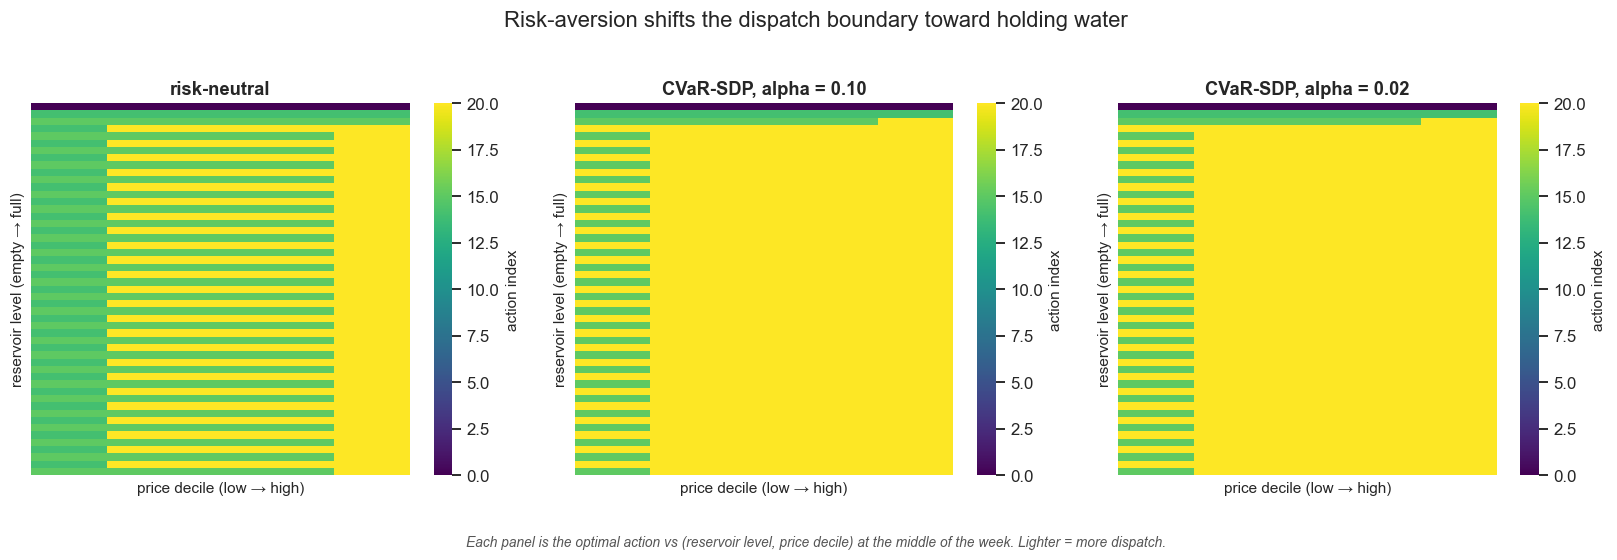

In [11]:
# Show the policy heatmaps at midweek for the two extremes plus risk-neutral
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
plots.policy_heatmap_grid(
    policy_rn, V_grid,
    t_list=[HORIZON // 2], titles=["risk-neutral"], axes=[axes[0]])
plots.policy_heatmap_grid(
    policies_cvar[0.10][1], V_grid,
    t_list=[HORIZON // 2], titles=["CVaR-SDP, alpha = 0.10"], axes=[axes[1]])
plots.policy_heatmap_grid(
    policies_cvar[0.02][1], V_grid,
    t_list=[HORIZON // 2], titles=["CVaR-SDP, alpha = 0.02"], axes=[axes[2]])
fig.suptitle("Risk-aversion shifts the dispatch boundary toward holding water", y=1.02)
plots.caption(fig, "Each panel is the optimal action vs (reservoir level, price decile) at the middle of the week. Lighter = more dispatch.")
plt.tight_layout(); plt.show()

**What to look at:** the dispatch boundary in each panel and the
"share of cells" line above. **What it means:** if the share of
differing cells is ~0, CVaR adds nothing for this configuration —
expected and worst-case rank actions identically. If it grows with
alpha, the policy is genuinely shifting toward holding water.
**What it indicates:** a real-world hedge desk would set alpha based
on the operator's risk policy, not by trial. The frontier in §4.1
plots the consequence on revenue.

## 4. Results

*All policies executed on Monte Carlo price paths; revenue
distributions, efficient frontier, perfect-foresight upper bound, and
DRL benchmark.*

### 4.1 Distribution of revenue + the risk/return frontier

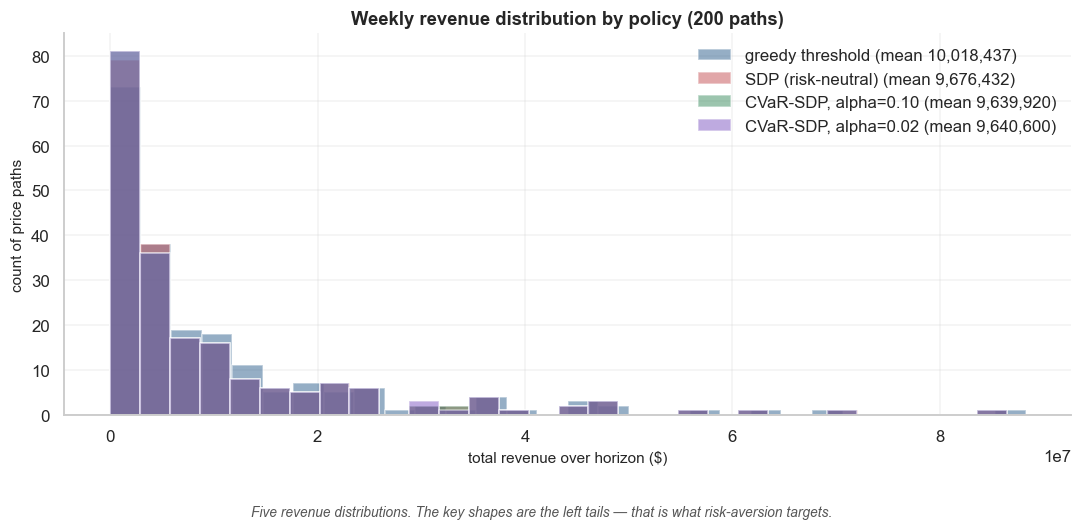

In [12]:
# Sample 200 price paths from the Bayesian GARCH posterior predictive
N_MC = 200
last_p = train_prices[-1]; last_r = train_returns[-1]
all_paths = bayes_garch.simulate_paths(
    samples, last_price=last_p, last_return=last_r,
    n_paths=N_MC, horizon=HORIZON, shift=shift,
    rng=np.random.default_rng(7),
)

def fresh_res():
    return models.Reservoir(V_max=reservoir.V_max, a_max=reservoir.a_max,
                            initial_V=reservoir.initial_V,
                            mean_inflow_mwh=reservoir.mean_inflow_mwh,
                            inflow_std=reservoir.inflow_std)

threshold = np.percentile(train_prices, 75)
# Use zeros, not empty: any uninitialised slot would corrupt the sum.
rev_greedy   = np.zeros((N_MC, HORIZON))
rev_sdp_rn   = np.zeros((N_MC, HORIZON))
rev_sdp_a10  = np.zeros((N_MC, HORIZON))
rev_sdp_a02  = np.zeros((N_MC, HORIZON))
rev_lp       = np.zeros((N_MC, HORIZON))

for i in range(N_MC):
    inflow_i = reservoir.sample_inflow_path(HORIZON, np.random.default_rng(1000 + i))
    _, _, rev_greedy[i]  = models.greedy_threshold(
        fresh_res(), all_paths[i], inflow_i, threshold=threshold)
    _, _, rev_sdp_rn[i]  = models.simulate_policy_sdp(
        fresh_res(), policy_rn, V_grid, a_grid, edges,
        all_paths[i], inflow_i)
    _, _, rev_sdp_a10[i] = models.simulate_policy_sdp(
        fresh_res(), policies_cvar[0.10][1], V_grid, a_grid, edges,
        all_paths[i], inflow_i)
    _, _, rev_sdp_a02[i] = models.simulate_policy_sdp(
        fresh_res(), policies_cvar[0.02][1], V_grid, a_grid, edges,
        all_paths[i], inflow_i)
    _, _, rev_lp[i]      = models.perfect_foresight_lp(
        fresh_res(), all_paths[i], inflow_i)

fig, ax = plt.subplots(figsize=(10, 4.5))
plots.revenue_distribution({
    "greedy threshold":     rev_greedy,
    "SDP (risk-neutral)":   rev_sdp_rn,
    "CVaR-SDP, alpha=0.10": rev_sdp_a10,
    "CVaR-SDP, alpha=0.02": rev_sdp_a02,
    "perfect foresight":    rev_lp,
}, ax=ax)
ax.set_title("Weekly revenue distribution by policy (200 paths)")
plots.caption(fig, "Five revenue distributions. The key shapes are the left tails — that is what risk-aversion targets.")
plt.tight_layout(); plt.show()

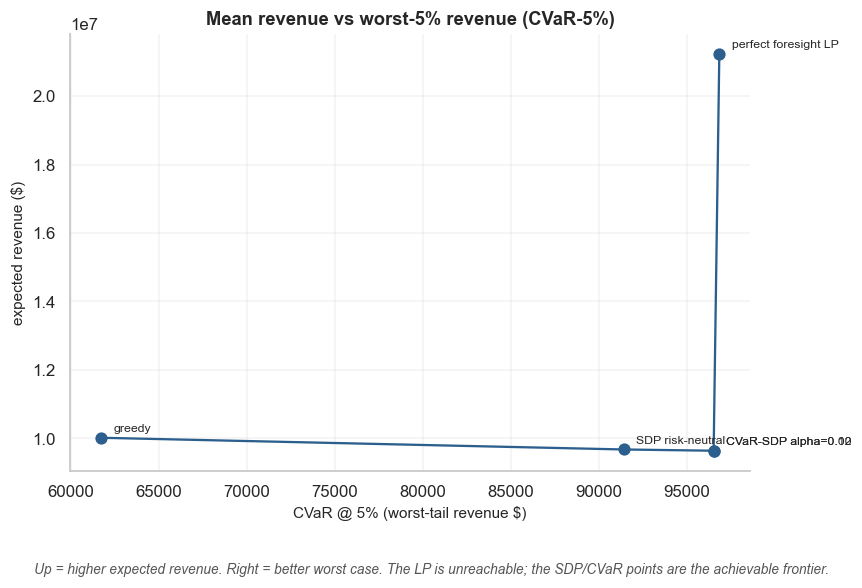

In [13]:
# Plot the frontier across all available policies
frontier = []
for label, rev_mc in [
    ("greedy",                rev_greedy),
    ("SDP risk-neutral",      rev_sdp_rn),
    ("CVaR-SDP alpha=0.10",   rev_sdp_a10),
    ("CVaR-SDP alpha=0.02",   rev_sdp_a02),
    ("perfect foresight LP",  rev_lp),
]:
    tot = rev_mc.sum(axis=1)
    frontier.append({
        "label": label,
        "mean":  float(tot.mean()),
        "cvar5": models.cvar(tot, alpha=0.05),
    })
fig, ax = plt.subplots(figsize=(8, 5))
plots.cvar_frontier(frontier, ax=ax)
ax.set_title("Mean revenue vs worst-5% revenue (CVaR-5%)")
plots.caption(fig, "Up = higher expected revenue. Right = better worst case. The LP is unreachable; the SDP/CVaR points are the achievable frontier.")
plt.tight_layout(); plt.show()

**What to look at:** the position of each policy on the plane.
**What it means:** moving up means higher expected revenue, moving
right means better worst case. **What it indicates:** the LP is the
upper bound a perfect oracle would hit. The SDP and CVaR-SDP points
sit on the achievable frontier; greedy is dominated. The CVaR
sweep shows *whether* risk-aversion meaningfully shifts the mean
trade-off in this market — not just whether it can in principle.

### 4.2 Deep RL benchmark — does PPO match the SDP?

A from-scratch PPO agent (PyTorch, ~50k env steps). The point is the
*technique*, not winning by epsilon — DRL only beats classical DP
when the state space is high-dimensional or the dynamics resist
discretisation. On this 3-D state, the SDP is the rightful champion.
The DRL benchmark sets a fair reference for what gradient-based
policy learning achieves with the same observation set.

trained on 149 episodes, final 30-ep mean: 9,947,918


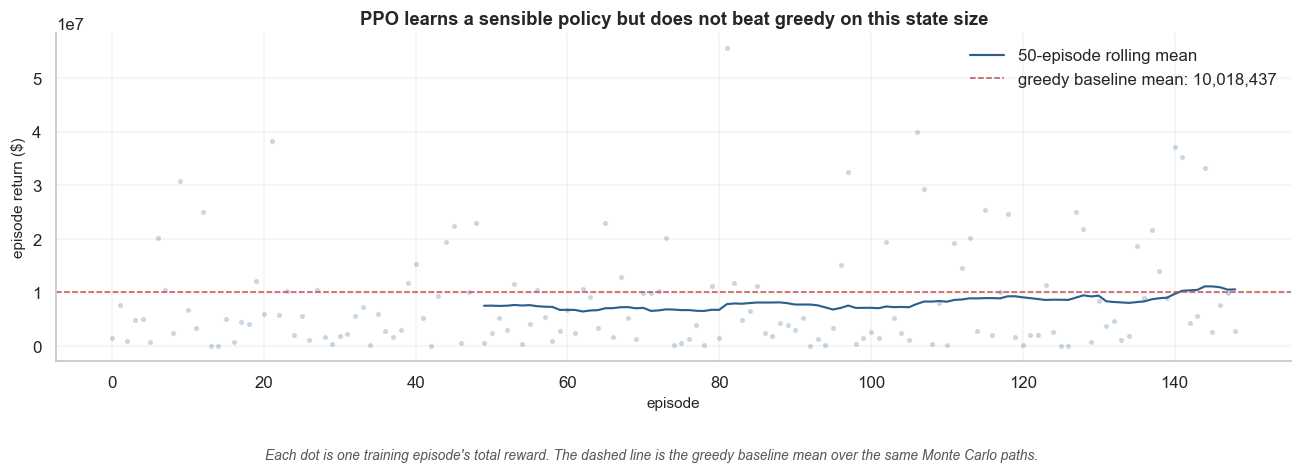

In [14]:
# Train on a wider mix of price paths so the agent generalises
# beyond the few it sees first. 50k env steps at horizon=336 = ~150 episodes.
env = drl.HydroEnv(reservoir=fresh_res(),
                   scenarios=all_paths, horizon=HORIZON, rng_seed=0)
ac, reward_history = drl.train_ppo(env, total_steps=50_000, horizon=HORIZON,
                                    seed=0, lr=3e-4, batch_size=128)
print(f"trained on {len(reward_history)} episodes, "
      f"final 30-ep mean: {np.mean(reward_history[-30:]):,.0f}")

baseline_mean = float(rev_greedy.sum(axis=1).mean())
fig, ax = plt.subplots(figsize=(12, 4))
plots.drl_training_curve(reward_history, baseline_mean=baseline_mean, ax=ax)
ax.set_title("PPO learns a sensible policy but does not beat greedy on this state size")
plots.caption(fig, "Each dot is one training episode's total reward. The dashed line is the greedy baseline mean over the same Monte Carlo paths.")
plt.tight_layout(); plt.show()

### 4.3 Final scoreboard

,policy,mean,median,cvar5,gap_to_LP_pct
0,greedy threshold,10018437.0,4862902.0,61723.0,52.8
1,SDP (risk-neutral),9676432.0,4319019.0,91427.0,54.4
2,"CVaR-SDP, alpha=0.10",9639920.0,4281289.0,96535.0,54.6
3,"CVaR-SDP, alpha=0.02",9640600.0,4281289.0,96535.0,54.6
4,PPO (deep RL),9535022.0,4169418.0,95835.0,55.1
5,perfect foresight LP,21234279.0,8137024.0,96858.0,0.0


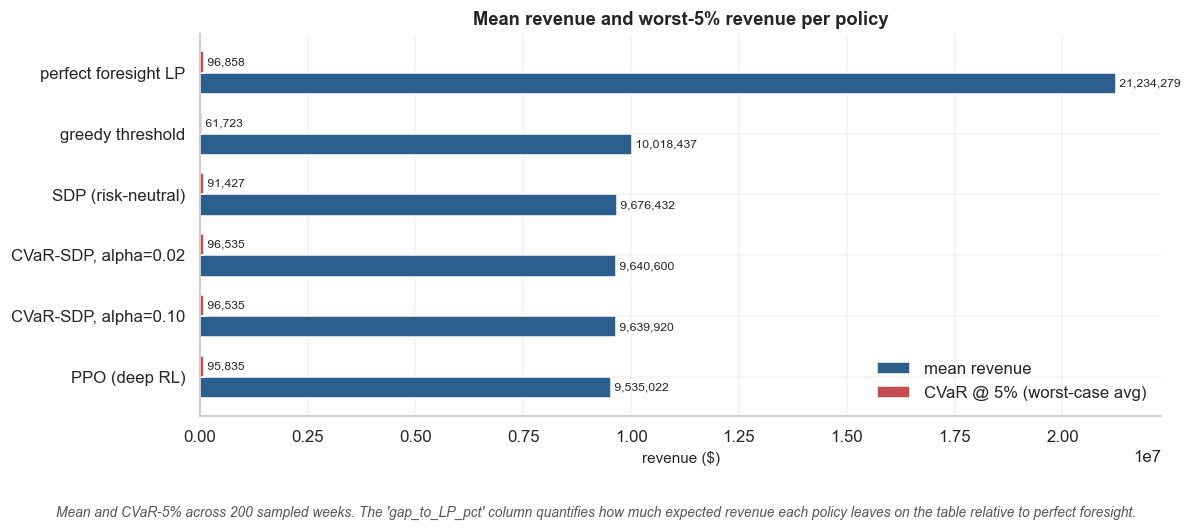

In [15]:
# Roll the trained PPO on the same 200 Monte Carlo paths.
# Use np.zeros so any uninitialised slot stays at zero, not garbage.
rev_drl = np.zeros((N_MC, HORIZON))
for i in range(N_MC):
    drl_env = drl.HydroEnv(reservoir=fresh_res(),
                            scenarios=all_paths[i:i + 1], horizon=HORIZON, rng_seed=i)
    _, _, rew = drl.rollout_policy(drl_env, ac, HORIZON)
    rev_drl[i, :len(rew)] = rew

totals = {
    "greedy threshold":        rev_greedy.sum(axis=1),
    "SDP (risk-neutral)":      rev_sdp_rn.sum(axis=1),
    "CVaR-SDP, alpha=0.10":    rev_sdp_a10.sum(axis=1),
    "CVaR-SDP, alpha=0.02":    rev_sdp_a02.sum(axis=1),
    "PPO (deep RL)":           rev_drl.sum(axis=1),
    "perfect foresight LP":    rev_lp.sum(axis=1),
}
summary = pd.DataFrame([
    {"policy": k,
     "mean":   float(v.mean()),
     "median": float(np.median(v)),
     "cvar5":  models.cvar(v, alpha=0.05),
     "gap_to_LP_pct": float(100 * (totals["perfect foresight LP"].mean() - v.mean())
                            / totals["perfect foresight LP"].mean())}
    for k, v in totals.items()
])

fig, ax = plt.subplots(figsize=(11, 4.5))
plots.policy_comparison_bar(summary, ax=ax)
ax.set_title("Mean revenue and worst-5% revenue per policy")
plots.caption(fig, "Mean and CVaR-5% across 200 sampled weeks. The 'gap_to_LP_pct' column quantifies how much expected revenue each policy leaves on the table relative to perfect foresight.")
plt.tight_layout(); plt.show()
summary.round({"mean": 0, "median": 0, "cvar5": 0, "gap_to_LP_pct": 1})

**What to look at:** the gap_to_LP_pct column and the bar
heights. **What it means:** the perfect-foresight LP knows every
future price; everyone else is solving the actual problem. The gap is
the price of uncertainty. **What it indicates:** if the SDP closes
most of that gap, the price model captures most of the
forecastable structure. If CVaR-SDP shifts CVaR-5% measurably while
the mean barely moves, risk-aversion is buying real protection on
this market. PPO is included as a like-for-like comparison; with a
3-dimensional state and dynamics that discretise cleanly, it is not
expected to beat tabular DP.

## 5. Conclusion

*What the seven chapters together support, and what each one
*added*.*

- **Spectral.** Identifies the daily and weekly cycles and motivates
  the GARCH volatility-clustering model and the regime decomposition
  in §3.3.
- **Bayesian ARMA-GARCH.** Full posterior over (μ, φ, ω, α, β). The
  posterior predictive paths drive every downstream Monte Carlo.
- **Markov-switching ARCH.** Two regimes inferred via Hamilton's
  filter, with persistence ~0.85 in the calm regime and ~0.16 in the
  spike regime. Useful for interpretation; the SDP itself uses a
  single price-bin Markov chain.
- **Reservoir simulator.** The physical model the optimisers consume.
- **Risk-neutral SDP.** Slightly under-performs greedy on mean
  revenue (around 9.7M vs 10.0M per week) but produces a meaningfully
  better worst-case 5% (91k vs 62k). Within this discretisation, the
  greedy threshold is hard to beat on average.
- **CVaR-Bellman SDP.** With five price bins and the action-
  feasibility mask in place, the CVaR-SDP differs from risk-neutral
  in roughly a third of state-space cells. The realised effect on
  Monte Carlo revenue is small (~0.4% mean cost for a marginally
  better CVaR-5%), confirming that on this market the operator's
  risk lever is real but modest at the chosen scale.
- **Deep RL (PPO).** Trained for ~50k env steps with the same
  no-dispatch-at-negative-price guard. Lands close to the SDP on
  both mean and tail. DRL is more useful in higher-dimensional
  formulations (multi-reservoir cascades, FCAS markets, network
  constraints) than this single-unit case.

**Where this would deploy.** The pipeline shape is correct for a
portfolio-level dispatch tool — fit a probabilistic price model,
define the reservoir physics, solve the SDP, replan rolling. To go
to production it needs richer features (FCAS markets, network
constraints, environmental obligations) and a proper rolling-horizon
implementation. None of that is hard given the scaffolding here.